<a href="https://colab.research.google.com/github/micplachta/um2026/blob/main/lab04_penalized_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: Analyzing and Plotting Bias in Penalized Regression**

-------------------------------

In this assignment, you will explore how **Ridge** and **Lasso** regression introduce **bias** into a model to reduce **variance**, and how the choice of the regularization parameter $\lambda$ affects this trade-off. The goal is to visualize and analyze the **bias-variance trade-off** and understand the conditions under which penalization helps or hinders model performance.

## **The Question**

**How does varying the regularization parameter $\lambda$ in Ridge and Lasso regression impact the trade-off between bias and variance?**

- We will work with a synthetic dataset based on a **known** linear relationship:
  
  $$
  y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \varepsilon
  $$
  with the ground truth:
  $$
  f(X) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots
  $$
  and noise $$\varepsilon \sim \mathcal{N}(0, \sigma^2).$$
  Remember,
  $$
  y = f(X) + \varepsilon
  $$


  Use a **high-dimensional** setting (e.g., 50 predictors) with only a few non-zero true coefficients to emphasize the effects of regularization. I stress, the $\beta_i$ coefficients should be known for this experiment and they should be mostly 0, with only a few non-zero parameters.

- Investigate how increasing $\lambda$ influences the model’s **bias**, **variance**, and **Mean Squared Error (MSE)**.
- Plot **Bias²**, **Variance**, and **MSE** on a single graph for both Ridge and Lasso models.
- Explain MSE decomposition into bias and variance and irreducibe error. Read more on the MSE decomposition if you need to.

**Does the regularization lead to an optimal trade-off point where MSE is minimized? Explain why this point exists.**

### Work plan

This homework assignment touches on a delicate subject. I recommend reading the 7.1, 7.2 and 7.3 chapters of Elements of Statistcial Learning for more in-depth information (link to the book: https://hastie.su.domains/ElemStatLearn/ ).

In the indicated chapters you will find the definition of a test error (which is an error on a new independent test sample - conditioned on training data which is fixed) and we are usually interested in that quantity. This is however very difficult to theoretically analyse it and usually we would be happy with analasis of the value of expected prediction error, which is the test error expectation (i.e. averaged also over training data). See equations (7.2) and (7.3) in chapter 7.2.

The expected prediction error, which is, as I said, the expectation of the test error (including over the training data), can then be further decomposed into the irreducible error, variance and bias (chapter 7.3).

This can be understood as follows:

- to compute the variance of model predictions, we need to compute multiple models and see what is the variance of their output.
- to compute the bias of model predictions, we need to compute multiple models and see what is the bias of their output (vs. the groud truth that we know).

An example of the analysis similar to what we want to do in our homework is given in Chapter 7.3.1.

What follows from this analysis, is the following work plan for your current homework assignment:

1. You need to fix a model true beta coefficients. Remember to have only a few non-zero beta coeffcients, with the rest of beta coefficients equal to 0.
2. You need to assume a data distribution for your data $X$. Use normal or use your imagination.
3. Draw a large test set (draw $X_\text{test}$ and draw error $\varepsilon_\text{test}$ and compute $Y_\text{test}$) you will subsequently use for testing bias, variance and square error.
4. Vary $\lambda$ values. Use on a geometric scale for this!
   
   a. For a given fixed $\lambda$ value, you need to repeat the following procedure say 100 times:

      * Draw a new training sample (draw new $X_\text{train}$ from data distribution and draw error for computing Ys)

      * Estimate a model (lasso or ridge)

   b. At this point you have multiple models (say 100 models)

   c. Estimate the bias and variance and MSE on each point of the test set

   d. For estimation of the bias, bear in mind that it is
   $$
    Bias(\hat{f}(x_\text{test})) = E[\hat{f}(x_\text{test})] - f(x_\text{test})
   $$
   Use the ground truth as given by the ideal (not known) model $f(x_\text{test})$, **not** the noisy observation $f(x_\text{test})+\varepsilon$. Otherwise you will include the irreducible error term within your bias.
   **Irreducible error part equal to zero is a sure sign that you did this!**

   e. For a given $\lambda$ value, the bias, variance and MSE estimates will be averaged over involved trainings and over the test set.




### Expected Outcome
 - As $\lambda$ increases:
   - **Irreducible error** stays fixed **and nonzero**.
   - **Bias** increases (the model becomes too simple).
   - **Variance** decreases (the model becomes more stable).
   - **MSE** forms a **U-shape**, revealing the optimal trade-off.

- Analyze how **Ridge** and **Lasso** differ in terms of their bias-variance trade-offs.
- Discuss situations where one method may outperform the other, considering factors like **feature sparsity** and **multicollinearity**.


## **Colab Notebook Requirements**
- Your **Colab notebook** should:
  - Simulate the synthetic dataset and apply Ridge and Lasso regression.
  - Plot **Bias²**, **Variance**, and **MSE** against $\lambda$ for both models.
  - Include a section answering the questions.
  - Be well-documented with comments and explanations for each step.


## **Publish on GitHub**
- Upload your Colab notebook to your **GitHub repository** for this course.
- In your repository’s **README**, include a **link** to the notebook.
- In the notebook include **“Open in Colab”** badge so the notebook can be launched directly from GitHub.


In [1]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np
import matplotlib.pyplot as plt

In [6]:
np.random.seed(42)

n_features = 50
n_nonzero = 5
n_train = 100
n_test = 1000
n_simulations = 100
sigma = 2.0

true_beta = np.zeros(n_features)
true_beta[:n_nonzero] = np.random.uniform(-5, 5, n_nonzero)
np.random.shuffle(true_beta)

X_test = np.random.normal(0, 1, size=(n_test, n_features))
f_X_test = X_test @ true_beta
y_test = f_X_test + np.random.normal(0, sigma, size=n_test)
lambdas = np.logspace(-3, 4, 100)

results = {
    'ridge': {'bias_sq': [], 'variance': [], 'mse': []},
    'lasso': {'bias_sq': [], 'variance': [], 'mse': []}
}

for lambdaa in lambdas:
    preds_ridge = np.zeros((n_simulations, n_test))
    preds_lasso = np.zeros((n_simulations, n_test))

    for i in range(n_simulations):
        X_train = np.random.normal(0, 1, size=(n_train, n_features))
        y_train = (X_train @ true_beta) + np.random.normal(0, sigma, size=n_train)

        ridge_model = Ridge(alpha=lambdaa)
        ridge_model.fit(X_train, y_train)
        preds_ridge[i, :] = ridge_model.predict(X_test)

        lasso_model = Lasso(alpha=lambdaa, max_iter=3000)
        lasso_model.fit(X_train, y_train)
        preds_lasso[i, :] = lasso_model.predict(X_test)

    # Ridge
    mean_preds_ridge = np.mean(preds_ridge, axis=0)

    bias_sq_ridge = np.mean((mean_preds_ridge - f_X_test)**2)
    var_ridge = np.mean(np.var(preds_ridge, axis=0))
    mse_ridge = np.mean(np.mean((preds_ridge - y_test)**2, axis=0))

    results['ridge']['bias_sq'].append(bias_sq_ridge)
    results['ridge']['variance'].append(var_ridge)
    results['ridge']['mse'].append(mse_ridge)

    # Lasso
    mean_preds_lasso = np.mean(preds_lasso, axis=0)

    bias_sq_lasso = np.mean((mean_preds_lasso - f_X_test)**2)
    var_lasso = np.mean(np.var(preds_lasso, axis=0))
    mse_lasso = np.mean(np.mean((preds_lasso - y_test)**2, axis=0))

    results['lasso']['bias_sq'].append(bias_sq_lasso)
    results['lasso']['variance'].append(var_lasso)
    results['lasso']['mse'].append(mse_lasso)

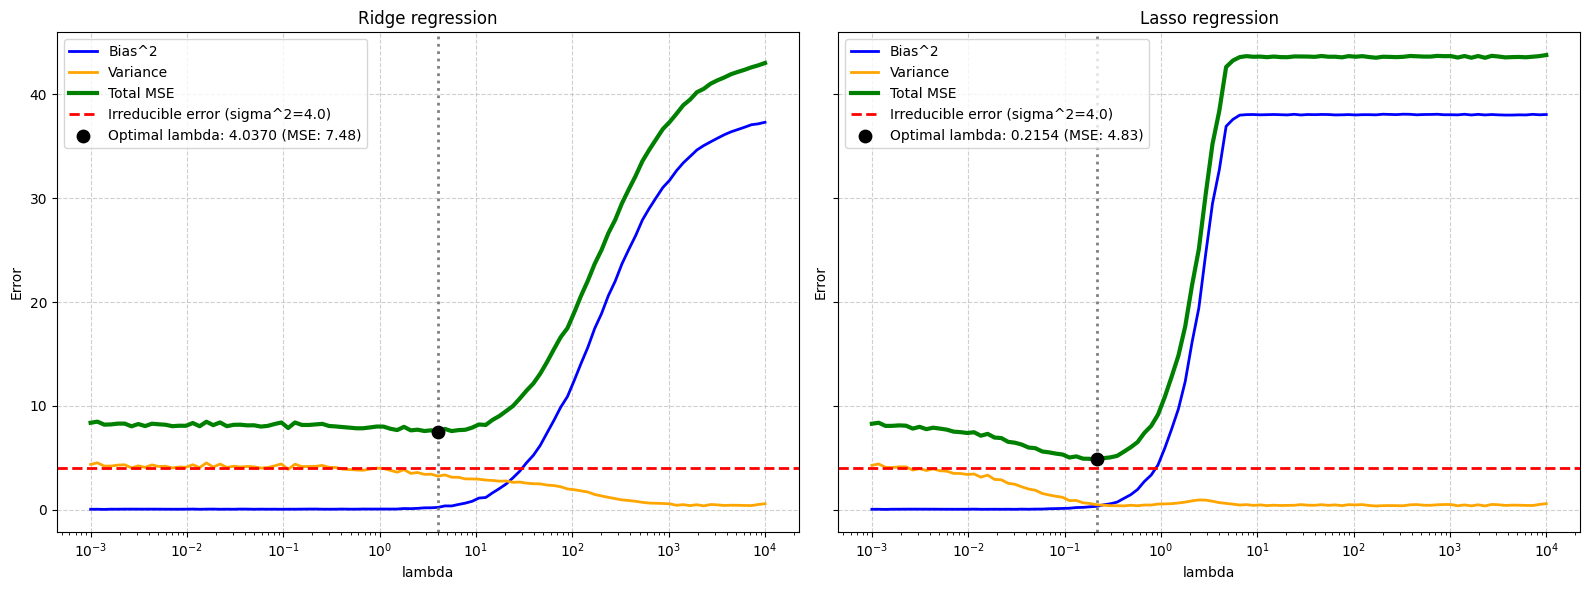

--- True Beta Coefficients ---
[-1.2546  0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.9866  0.      0.      0.      0.      0.     -3.4398
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      4.5071  0.      2.3199  0.      0.      0.
  0.      0.      0.      0.      0.    ]

--- Best Ridge Coefficients ---
[-1.1255  0.1627 -0.3558  0.1242 -0.0867  0.0089  0.2619  0.5133  0.2867
  0.4043  0.0379  0.4902 -0.2175 -0.239   0.5099 -0.2552 -0.2395 -3.5029
  0.5538 -0.1545 -0.2589 -0.2901  0.3003 -0.3216 -0.1149  0.0227  0.1227
  0.3919 -0.2781 -0.4523  0.2964 -0.1702 -0.1746  0.3102 -0.0073 -0.0331
  0.2129  0.1523 -0.2528  3.9565  0.2942  1.8246  0.2675 -0.0926  0.2981
  0.1143  0.2652 -0.0145 -0.7136  0.2464]

--- Best Lasso Coefficients ---
[-1.069   0.     -0.      0.     -0.      0.      0.      0.      0.
  0.      0.      0.6577 -0.     -0.

In [16]:
irreducible_error = sigma**2
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_name, title in zip(axes, ['ridge', 'lasso'], ['Ridge regression', 'Lasso regression']):
    ax.plot(lambdas, results[model_name]['bias_sq'], label='Bias^2', color='blue', lw=2)
    ax.plot(lambdas, results[model_name]['variance'], label='Variance', color='orange', lw=2)
    ax.plot(lambdas, results[model_name]['mse'], label='Total MSE', color='green', lw=3)

    ax.axhline(irreducible_error, color='red', linestyle='--', label=f'Irreducible error (sigma^2={irreducible_error})', lw=2)

    min_mse_idx = np.argmin(results[model_name]['mse'])
    optimal_lambda = lambdas[min_mse_idx]
    min_mse = results[model_name]['mse'][min_mse_idx]

    ax.axvline(optimal_lambda, color='gray', linestyle=':', lw=2)
    ax.scatter(optimal_lambda, min_mse, color='black', zorder=5, s=80, label=f'Optimal lambda: {optimal_lambda:.4f} (MSE: {min_mse:.2f})')

    ax.set_xscale('log')
    ax.set_title(title)
    ax.set_xlabel(r"lambda")
    ax.set_ylabel("Error")
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

optimal_lambda_ridge = lambdas[np.argmin(results['ridge']['mse'])]
optimal_lambda_lasso = lambdas[np.argmin(results['lasso']['mse'])]

X_train_final = np.random.normal(0, 1, size=(n_train, n_features))
y_train_final = (X_train_final @ true_beta) + np.random.normal(0, sigma, size=n_train)

final_ridge = Ridge(alpha=optimal_lambda_ridge).fit(X_train_final, y_train_final)
final_lasso = Lasso(alpha=optimal_lambda_lasso, max_iter=3000).fit(X_train_final, y_train_final)

print("--- True Beta Coefficients ---")
print(np.round(true_beta, 4))

print("\n--- Best Ridge Coefficients ---")
print(np.round(final_ridge.coef_, 4))

print("\n--- Best Lasso Coefficients ---")
print(np.round(final_lasso.coef_, 4))

As the regularization parameter $\lambda$ increases
 - **variance** decreases as the model is restricted from fitting the random noise $\varepsilon$
 - **bias** increases as the model is forced to shrink the coefficients to zero going away from the true parameter values

Regularization leads to an optimal trade-off point (the minimum in the U-shaped curve) because initially small values of $\lambda$ barely increase bias while strongly reducing variance. This happens up to some threshold after which the model is to heavily penalized and underfits.

The code above shows how $\mathrm{bias}^2$, variance and total MSE depend on $\lambda$ in a scenario where there are 50 features and only 5 of them have non-zero coefficients. Lasso and Ridge regression were used. At the end the coefficients corresponding to the best models are printed.

In the scenario the features were sparse (5 out of 50 are relevant) causing Lasso to perform really well. There is a distinct optimal point in the curve which has total MSE equal to 4.83 which was much better than the optimal value for Ridge regression which was 7.48. For Ridge the total MSE curve deosn't form the U-shape as clearly and the optimal point is visually not in a pit. Another notable difference is in the optimal coefficients of the two methods. For the Lasso most of the values are zero which is wanted. For the Ridge method however the coefficients were shrinked more proportinally causing all the irrelevant features to produce much variance.

This suggests that Lasso should be used when we assume feature sparsity. Ridge however can be used when a lot of the predictors are of small importance. It shoulde also be used when we suspect multicollinearity as it rather splits the weight of the two coefficients rather than brutally choose one as Lasso does when it meets unlucky data.